# Google Trends — Data Collection

This notebook retrieves daily Google Trends search interest data for keywords related to the 2024 US presidential election.

**Period:** July 5, 2024 – November 4, 2024  
**Geography:** United States (`geo='US'`)

### Why US-only?
The election is a domestic US event. Restricting to `geo='US'` ensures the index reflects **American public attention** — directly comparable to polls and Polymarket odds. Global data would mix in international curiosity that carries no signal about the actual outcome.

### What is extracted?
| Feature | Description |
|---|---|
| `interest_over_time` | Daily index (0–100) of relative search volume. 100 = peak day in the window. **Main feature for the predictive model.** |
| `interest_by_region` | Search interest per US state. Useful for geographic descriptive analysis. |
| `related_queries` | Top & rising queries associated with each keyword. Captures narrative shifts. |

### Technical note — stitching windows
pytrends only returns **daily** granularity for windows ≤ 90 days. July 5 → November 4 is 123 days.  
Solution: pull two overlapping windows and rescale using the overlap period to stitch them onto a common scale.

- **Window 1:** 2024-07-05 → 2024-10-02 (90 days)
- **Window 2:** 2024-08-26 → 2024-11-04 (71 days, overlaps with window 1 from Aug 26 – Oct 2)
- **Overlap:** 2024-08-26 → 2024-10-02 (~37 days) — used to compute per-keyword rescaling factors

Raw data (both windows + stitched result) is saved to `Data/1_Bronze/Google Trends/`.

<!-- toc -->
## Contents
- **[Google Trends — Data Collection](#google-trends-data-collection)**
    - [Why US-only?](#why-us-only)
    - [What is extracted?](#what-is-extracted)
    - [Technical note — stitching windows](#technical-note-stitching-windows)
  - [1. Fetch `interest_over_time` — all keywords](#1-fetch-interest_over_time-all-keywords)
  - [2. Fetch `interest_by_region` (US states)](#2-fetch-interest_by_region-us-states)
  - [4. Fetch daily `trump` time series per state](#4-fetch-daily-trump-time-series-per-state)
  - [6. Fetch `related_queries`](#6-fetch-related_queries)
  - [Summary](#summary)


In [39]:
#%pip install pytrends pandas

In [40]:
import time
import pandas as pd
from pytrends.request import TrendReq

# ── Configuration ─────────────────────────────────────────────────────────────

KEYWORDS = [
    'trump', 'kamala', 'biden', 'elon musk',
    'election 2024', 'vote', 'conspiracy',
    'walz', 'vance', 'campaign',
]

GEO = 'US'
CATEGORY = 0

WINDOW_1 = ('2024-07-05', '2024-10-02')
WINDOW_2 = ('2024-08-26', '2024-11-04')
OVERLAP_START = '2024-08-26'
OVERLAP_END   = '2024-10-02'

ANCHOR = 'trump'
BATCHES = [
    ['trump', 'kamala', 'biden', 'elon musk', 'election 2024'],
    ['trump', 'vote', 'conspiracy', 'walz', 'vance'],
    ['trump', 'campaign'],
]

BRONZE_PATH = '../../Data/1_Bronze/Google Trends/'

print('Configuration loaded.')
print(f'  Keywords  : {KEYWORDS}')
print(f'  Anchor    : {ANCHOR}')
print(f'  Geography : {GEO}')
print(f'  Window 1  : {WINDOW_1[0]} → {WINDOW_1[1]}')
print(f'  Window 2  : {WINDOW_2[0]} → {WINDOW_2[1]}')

Configuration loaded.
  Keywords  : ['trump', 'kamala', 'biden', 'elon musk', 'election 2024', 'vote', 'conspiracy', 'walz', 'vance', 'campaign']
  Anchor    : trump
  Geography : US
  Window 1  : 2024-07-05 → 2024-10-02
  Window 2  : 2024-08-26 → 2024-11-04


## 1. Fetch `interest_over_time` — all keywords

In [46]:
pytrends = TrendReq(hl='en-US', tz=360, timeout=(10, 25))

def fetch_window(timeframe, keywords, geo=GEO):
    pytrends.build_payload(keywords, cat=CATEGORY, timeframe=timeframe, geo=geo)
    df = pytrends.interest_over_time()
    if df.empty:
        raise ValueError(f'Empty response for timeframe={timeframe}, geo={geo}')
    df = df.drop(columns=['isPartial'], errors='ignore')
    df.index = pd.to_datetime(df.index)
    return df

def stitch(df_w1, df_w2, keywords):
    """Rescale window 2 to window 1 scale using overlap period, then concatenate."""
    w1_ov = df_w1.loc[OVERLAP_START:OVERLAP_END]
    w2_ov = df_w2.loc[OVERLAP_START:OVERLAP_END]
    df_w2s = df_w2.copy()
    for kw in keywords:
        m1, m2 = w1_ov[kw].mean(), w2_ov[kw].mean()
        df_w2s[kw] = (df_w2s[kw] * (m1 / m2 if m2 else 1.0)).clip(0, 100)
    w1_end = pd.Timestamp(WINDOW_1[1])
    out = pd.concat([df_w1, df_w2s.loc[w1_end + pd.Timedelta(days=1):]]).sort_index()
    return out[~out.index.duplicated(keep='first')]

tf1 = f"{WINDOW_1[0]} {WINDOW_1[1]}"
tf2 = f"{WINDOW_2[0]} {WINDOW_2[1]}"

# Step 1 — fetch & stitch each batch independently
batch_stitched = []
for i, batch in enumerate(BATCHES):
    print(f'Batch {i+1}/{len(BATCHES)}: {batch}')
    w1 = fetch_window(tf1, batch)
    time.sleep(5)
    w2 = fetch_window(tf2, batch)
    time.sleep(5)
    batch_stitched.append(stitch(w1, w2, batch))
    print(f'  stitched shape: {batch_stitched[-1].shape}')

# Step 2 — normalise batches 2+ to batch 1 using the anchor keyword
anchor_series = batch_stitched[0][ANCHOR]

normalised = [batch_stitched[0]]
for batch_df in batch_stitched[1:]:
    scaled = batch_df.copy()
    for day in scaled.index:
        anchor_b1 = anchor_series.loc[day] if day in anchor_series.index else None
        anchor_bn = scaled.loc[day, ANCHOR]
        if anchor_b1 and anchor_bn:
            factor = anchor_b1 / anchor_bn
            for col in scaled.columns:
                if col != ANCHOR:
                    scaled.loc[day, col] = min(scaled.loc[day, col] * factor, 100)
    normalised.append(scaled.drop(columns=[ANCHOR]))

# Step 3 — merge all into one dataframe
df_combined = pd.concat(normalised, axis=1).sort_index()
df_combined.index.name = 'date'
df_combined = df_combined[KEYWORDS]

df_combined.to_csv(f'{BRONZE_PATH}trends_daily_stitched.csv')
print(f'\nFinal dataset: {df_combined.shape[0]} days × {df_combined.shape[1]} keywords')
print(f'Date range: {df_combined.index.min().date()} → {df_combined.index.max().date()}')
df_combined.tail()

Batch 1/3: ['trump', 'kamala', 'biden', 'elon musk', 'election 2024']
  stitched shape: (123, 5)
Batch 2/3: ['trump', 'vote', 'conspiracy', 'walz', 'vance']
  stitched shape: (123, 5)
Batch 3/3: ['trump', 'campaign']
  stitched shape: (123, 2)

Final dataset: 123 days × 10 keywords
Date range: 2024-07-05 → 2024-11-04


,trump,kamala,biden,elon musk,election 2024,vote,conspiracy,walz,vance,campaign
date,,,,,,,,,,
2024-10-31,8.984950,2.809322,1.374046,0.115942,0.135135,5.550372,0.0,0.225753,0.554120,0.0
2024-11-01,8.485786,2.644068,0.824427,0.115942,0.162162,6.178592,0.0,0.221739,0.544269,0.0
2024-11-02,8.984950,2.974576,0.687023,0.115942,0.162162,5.920397,0.0,0.225753,0.554120,0.0
2024-11-03,9.317726,4.627119,0.687023,0.115942,0.229730,20.323448,0.0,0.225443,0.553360,0.0
2024-11-04,10.981605,4.957627,0.824427,0.115942,0.445946,36.745519,0.0,0.224185,0.275136,0.0


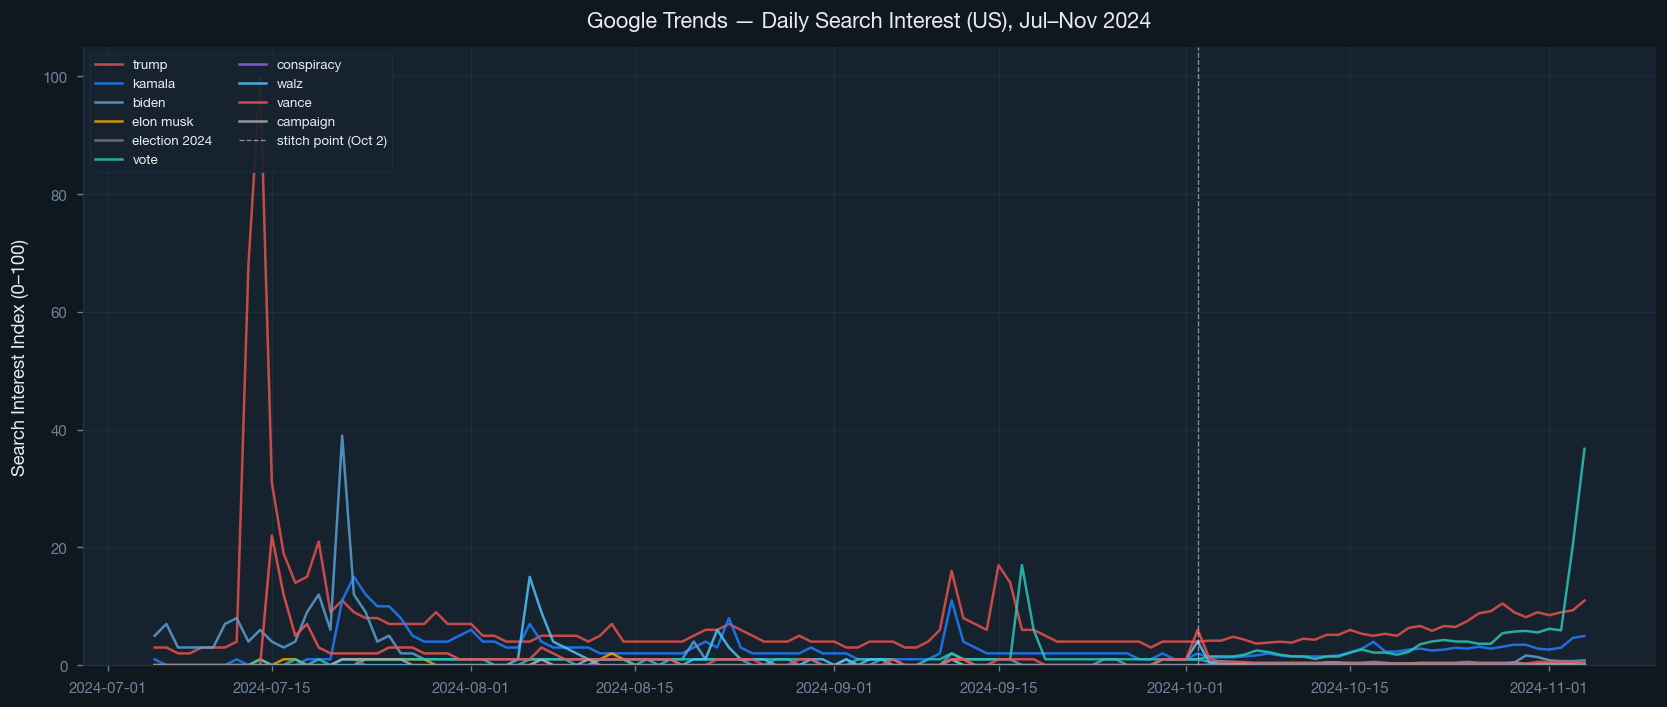

Preview saved.


In [42]:
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')
from house_style import REPUBLICAN, DEMOCRAT, NEUTRAL, TEXT_MUTED, apply_style, style_ax
apply_style()

COLOR_MAP = {
    'trump'         : REPUBLICAN,
    'kamala'        : DEMOCRAT,
    'biden'         : '#5a9fd4',
    'elon musk'     : '#f0a500',
    'election 2024' : NEUTRAL,
    'vote'          : '#2ec4b6',
    'conspiracy'    : '#9b5de5',
    'walz'          : '#4fc3f7',
    'vance'         : '#ef5350',
    'campaign'      : '#aaaaaa',
}

fig, ax = plt.subplots(figsize=(14, 6))
for kw in KEYWORDS:
    ax.plot(df_combined.index, df_combined[kw], label=kw,
            color=COLOR_MAP[kw], linewidth=1.5, alpha=0.85)
ax.axvline(pd.Timestamp(WINDOW_1[1]), color='white', linestyle='--',
           linewidth=0.8, alpha=0.5, label='stitch point (Oct 2)')
style_ax(ax, title='Google Trends — Daily Search Interest (US), Jul–Nov 2024',
         ylabel='Search Interest Index (0–100)')
ax.legend(fontsize=8, loc='upper left', ncol=2)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(f'{BRONZE_PATH}trends_daily_preview.png', dpi=150)
plt.show()
print('Preview saved.')

## 2. Fetch `interest_by_region` (US states)

In [43]:
time.sleep(5)

full_tf = "2024-07-05 2024-11-04"

# Fetch by-region per batch, normalise to batch 1 anchor, then merge
region_dfs = []
anchor_region = None

for i, batch in enumerate(BATCHES):
    pytrends.build_payload(batch, cat=CATEGORY, timeframe=full_tf, geo=GEO)
    df_r = pytrends.interest_by_region(resolution='REGION', inc_low_vol=True, inc_geo_code=False)
    if i == 0:
        anchor_region = df_r[ANCHOR]
        region_dfs.append(df_r)
    else:
        scaled = df_r.copy()
        for col in scaled.columns:
            if col != ANCHOR:
                mask = df_r[ANCHOR] > 0
                scaled.loc[mask, col] = (
                    scaled.loc[mask, col] / df_r.loc[mask, ANCHOR] * anchor_region.loc[mask]
                ).clip(0, 100)
        region_dfs.append(scaled.drop(columns=[ANCHOR]))
    time.sleep(5)

df_by_region = pd.concat(region_dfs, axis=1)[KEYWORDS]
df_by_region.to_csv(f'{BRONZE_PATH}trends_by_state.csv')
print(f'interest_by_region: {df_by_region.shape} — saved to trends_by_state.csv')
df_by_region.head()

/var/folders/4r/kx0lc74n42j94_8kv0y_lcm80000gn/T/ipykernel_84162/2646126599.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[14.93939394 12.60869565 16.36923077 16.66153846 12.35294118 12.14705882
 13.01470588 12.08955224 11.75       16.40909091 16.07692308 13.25714286
 15.85074627 14.46268657 16.95384615 17.8125     17.24615385 16.3125
 16.6969697  10.43478261 13.5        12.31343284 13.64705882 15.
 15.58208955 18.41269841 13.28571429 16.19047619 15.04477612 11.14285714
 12.82608696 13.68115942 13.81818182 16.625      14.80597015 15.671875
 16.06153846 12.11940299 13.88235294 13.04347826 15.58208955 15.47761194
 14.71641791 21.14516129 14.75        9.77142857 13.81818182 12.57352941
 12.17391304 15.1969697  12.22535211]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scaled.loc[mask, col] = (
/var/folders/4r/kx0lc74n42j94_8kv0y_lcm80000gn/T/ipykernel_84162

interest_by_region: (51, 10) — saved to trends_by_state.csv


,trump,kamala,biden,elon musk,election 2024,vote,conspiracy,walz,vance,campaign
geoName,,,,,,,,,,
Alabama,58,21,15,3,3,14.939394,0.00000,4.393939,10.545455,2.416667
Alaska,58,20,14,3,5,12.608696,0.84058,5.043478,7.565217,3.052632
Arizona,56,23,14,3,4,16.369231,0.00000,6.030769,7.753846,2.947368
Arkansas,57,21,15,3,4,16.661538,0.00000,5.261538,8.769231,2.375000
California,56,23,14,4,3,12.352941,0.00000,5.764706,8.235294,2.947368


## 4. Fetch daily `trump` time series per state

Fetches daily search interest for `trump` separately for all 51 US states.  
This enables time-series analysis per state and linking search spikes to events.

**Note:** 51 states × 2 windows = 102 requests. Allow ~20 minutes with rate-limit sleeps.

In [48]:
STATE_CODES = {
    'Alabama': 'US-AL', 'Alaska': 'US-AK', 'Arizona': 'US-AZ',
    'Arkansas': 'US-AR', 'California': 'US-CA', 'Colorado': 'US-CO',
    'Connecticut': 'US-CT', 'Delaware': 'US-DE', 'District of Columbia': 'US-DC',
    'Florida': 'US-FL', 'Georgia': 'US-GA', 'Hawaii': 'US-HI',
    'Idaho': 'US-ID', 'Illinois': 'US-IL', 'Indiana': 'US-IN',
    'Iowa': 'US-IA', 'Kansas': 'US-KS', 'Kentucky': 'US-KY',
    'Louisiana': 'US-LA', 'Maine': 'US-ME', 'Maryland': 'US-MD',
    'Massachusetts': 'US-MA', 'Michigan': 'US-MI', 'Minnesota': 'US-MN',
    'Mississippi': 'US-MS', 'Missouri': 'US-MO', 'Montana': 'US-MT',
    'Nebraska': 'US-NE', 'Nevada': 'US-NV', 'New Hampshire': 'US-NH',
    'New Jersey': 'US-NJ', 'New Mexico': 'US-NM', 'New York': 'US-NY',
    'North Carolina': 'US-NC', 'North Dakota': 'US-ND', 'Ohio': 'US-OH',
    'Oklahoma': 'US-OK', 'Oregon': 'US-OR', 'Pennsylvania': 'US-PA',
    'Rhode Island': 'US-RI', 'South Carolina': 'US-SC', 'South Dakota': 'US-SD',
    'Tennessee': 'US-TN', 'Texas': 'US-TX', 'Utah': 'US-UT',
    'Vermont': 'US-VT', 'Virginia': 'US-VA', 'Washington': 'US-WA',
    'West Virginia': 'US-WV', 'Wisconsin': 'US-WI', 'Wyoming': 'US-WY',
}

state_series = {}
total = len(STATE_CODES)

for i, (state, code) in enumerate(STATE_CODES.items()):
    print(f'[{i+1}/{total}] {state} ({code})')
    try:
        w1 = fetch_window(tf1, ['trump'], geo=code)
        time.sleep(10)
        w2 = fetch_window(tf2, ['trump'], geo=code)
        time.sleep(10)
        stitched_state = stitch(w1, w2, ['trump'])
        state_series[state] = stitched_state['trump']
    except Exception as e:
        print(f'  ERROR: {e} — skipping')
        time.sleep(15)

df_trump_states = pd.DataFrame(state_series)
df_trump_states.index.name = 'date'
df_trump_states.to_csv(f'{BRONZE_PATH}trump_daily_by_state.csv')
print(f'\nSaved: {df_trump_states.shape[0]} days × {df_trump_states.shape[1]} states')
df_trump_states.tail()

[1/51] Alabama (US-AL)
[2/51] Alaska (US-AK)
[3/51] Arizona (US-AZ)
[4/51] Arkansas (US-AR)
[5/51] California (US-CA)
[6/51] Colorado (US-CO)
[7/51] Connecticut (US-CT)
[8/51] Delaware (US-DE)
[9/51] District of Columbia (US-DC)
[10/51] Florida (US-FL)
[11/51] Georgia (US-GA)
[12/51] Hawaii (US-HI)
[13/51] Idaho (US-ID)
[14/51] Illinois (US-IL)
[15/51] Indiana (US-IN)
  ERROR: The request failed: Google returned a response with code 429 — skipping
[16/51] Iowa (US-IA)
[17/51] Kansas (US-KS)
[18/51] Kentucky (US-KY)
[19/51] Louisiana (US-LA)
[20/51] Maine (US-ME)
[21/51] Maryland (US-MD)
[22/51] Massachusetts (US-MA)
[23/51] Michigan (US-MI)
[24/51] Minnesota (US-MN)
[25/51] Mississippi (US-MS)
[26/51] Missouri (US-MO)
[27/51] Montana (US-MT)
[28/51] Nebraska (US-NE)
[29/51] Nevada (US-NV)
[30/51] New Hampshire (US-NH)
[31/51] New Jersey (US-NJ)
[32/51] New Mexico (US-NM)
[33/51] New York (US-NY)
[34/51] North Carolina (US-NC)
[35/51] North Dakota (US-ND)
[36/51] Ohio (US-OH)
[37/51] Ok

,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,District of Columbia,Florida,...,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
date,,,,,,,,,,,,,,,,,,,,,
2024-10-31,6.046324,6.562701,8.780799,7.122699,7.152941,7.681400,9.734189,8.592528,16.200361,7.826982,...,7.036204,7.259519,7.227358,6.074627,7.266667,8.485035,7.475149,7.357071,10.947368,5.826800
2024-11-01,5.568983,5.300643,9.112150,6.791411,7.152941,8.038674,10.166819,8.592528,16.200361,7.826982,...,5.838552,7.098196,7.073585,5.522388,8.074074,8.984155,7.101392,6.376128,11.430341,5.702826
2024-11-02,5.728097,7.446141,8.449448,6.791411,8.470588,9.289134,9.734189,9.152911,16.524368,7.826982,...,6.736791,6.936874,7.073585,6.488806,9.688889,12.644366,8.409543,7.193581,11.591331,4.339107
2024-11-03,6.046324,7.698553,8.283772,7.453988,9.035294,9.110497,11.032081,9.900087,16.200361,8.414006,...,6.587084,6.936874,7.227358,7.041045,11.101852,10.315141,8.783300,7.684052,9.337461,5.826800
2024-11-04,8.114804,7.446141,9.112150,8.282209,11.105882,9.289134,13.411549,10.460469,21.060469,9.588054,...,6.587084,8.711423,9.533962,7.869403,10.496296,10.647887,9.530815,10.136409,9.498452,5.950775


In [ ]:
# ── Patch: fetch Indiana which was skipped due to a transient error ───────────
# df_trump_states = pd.read_csv(f'{BRONZE_PATH}trump_daily_by_state.csv',
#                               index_col='date', parse_dates=True)

# print('Fetching Indiana (US-IN)...')
# w1 = fetch_window(tf1, ['trump'], geo='US-IN')
# time.sleep(10)
# w2 = fetch_window(tf2, ['trump'], geo='US-IN')
# stitched_in = stitch(w1, w2, ['trump'])
# df_trump_states['Indiana'] = stitched_in['trump']

# df_trump_states.to_csv(f'{BRONZE_PATH}trump_daily_by_state.csv')
# print(f'Done. Dataset now has {df_trump_states.shape[1]} states.')
# print('Indiana sample:', df_trump_states['Indiana'].describe().round(1))

Fetching Indiana (US-IN)...
Done. Dataset now has 51 states.
Indiana sample: count    123.0
mean       6.3
std       10.6
min        2.0
25%        3.0
50%        4.0
75%        6.0
max      100.0
Name: Indiana, dtype: float64


## 6. Fetch `related_queries`

In [44]:
time.sleep(10)

for batch in BATCHES:
    pytrends.build_payload(batch, cat=CATEGORY, timeframe=full_tf, geo=GEO)
    related_queries = pytrends.related_queries()
    for kw in batch:
        safe_name = kw.replace(' ', '_').lower()
        top    = related_queries[kw]['top']
        rising = related_queries[kw]['rising']
        if top is not None:
            top.to_csv(f'{BRONZE_PATH}related_queries_{safe_name}_top.csv', index=False)
        if rising is not None:
            rising.to_csv(f'{BRONZE_PATH}related_queries_{safe_name}_rising.csv', index=False)
        print(f'  {kw}: {len(top) if top is not None else 0} top, {len(rising) if rising is not None else 0} rising saved')
    time.sleep(5)

print('\nAll related queries saved.')

  trump: 25 top, 25 rising saved
  kamala: 25 top, 25 rising saved
  biden: 25 top, 25 rising saved
  elon musk: 25 top, 25 rising saved
  election 2024: 8 top, 3 rising saved
  trump: 25 top, 25 rising saved
  vote: 25 top, 25 rising saved
  conspiracy: 25 top, 24 rising saved
  walz: 25 top, 25 rising saved
  vance: 25 top, 25 rising saved
  trump: 25 top, 25 rising saved
  campaign: 25 top, 25 rising saved

All related queries saved.


## Summary

All raw data saved to `Data/1_Bronze/Google Trends/Storage/`:

| File | Contents |
|---|---|
| `trends_window1_raw.csv` | Raw daily index, window 1 (Jul 5 – Oct 2) |
| `trends_window2_raw.csv` | Raw daily index, window 2 (Aug 26 – Nov 24) |
| `trends_daily_stitched.csv` | **Main output** — stitched daily index, full period |
| `trends_daily_preview.png` | Quick validation plot |
| `trends_by_state.csv` | Search interest per US state (full period aggregate) |
| `related_queries_<keyword>_top.csv` | Top related queries per keyword |
| `related_queries_<keyword>_rising.csv` | Rising related queries per keyword |

Next step: `2_Descriptive_analysis.ipynb` — visualise trends, compare candidates, and compute features for the basetable.

For notebook `3_State_analysis.ipynb`: